In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, time, json, math, random, re, shutil
from pathlib import Path

PROJECT_NAME = "CSE499B_Lightweight_Diffusion"
ROOT = Path("/content/drive/MyDrive") / PROJECT_NAME

CKPT_DIR   = ROOT / "checkpoints_phase2"
SAMPLE_DIR = ROOT / "samples_phase2"
RESULT_DIR = ROOT / "results_phase2"
TMP_DIR    = Path("/content/tmp_phase2")

for d in [CKPT_DIR, SAMPLE_DIR, RESULT_DIR, TMP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("CKPT_DIR:", CKPT_DIR)
print("SAMPLE_DIR:", SAMPLE_DIR)
print("RESULT_DIR:", RESULT_DIR)
print("TMP_DIR:", TMP_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ROOT: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion
CKPT_DIR: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/checkpoints_phase2
SAMPLE_DIR: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/samples_phase2
RESULT_DIR: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/results_phase2
TMP_DIR: /content/tmp_phase2


In [2]:
!pip -q install torchmetrics torchvision tqdm einops torch-fidelity thop pandas matplotlib pillow

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils
from tqdm import tqdm
from einops import rearrange
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

def seed_all(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_all(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
print("gpu:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

device: cuda
gpu: NVIDIA A100-SXM4-40GB


In [4]:
BASE = {
    "dataset": "CIFAR10",
    "image_size": 32,
    "channels": 3,
    "batch_size": 256,
    "num_workers": 2,

    "T": 1000,
    "beta_start": 1e-4,
    "beta_end": 0.02,

    "epochs": 100,
    "lr": 2e-4,

    "ema": {
        "use": True,
        "decay": 0.999
    },

    "sample": {
        "n_samples": 64,
        "grid_rows": 8,
        "ddim_steps": 50,
        "ddim_eta": 0.0
    },

    "quick_eval": {
        "n_real": 200,
        "n_fake": 200,
        "ddim_steps": 20
    },

    "save_policy": {
        "save_latest_every": 5,
        "milestones": [75, 100],
        "save_samples_at": [75, 100]
    },

    "model": {
        "base_channels": 128,
        "channel_mults": [1, 2, 2, 2],
        "stage_widths": None,
        "use_attn": True,
        "use_depthwise": False
    }
}

import copy
EXPS = {}

EXPS["baseline_100"] = copy.deepcopy(BASE)

EXPS["depth_reduce_100"] = copy.deepcopy(BASE)
EXPS["depth_reduce_100"]["model"]["channel_mults"] = [1, 2, 2]

print("Experiments ready:", list(EXPS.keys()))

Experiments ready: ['baseline_100', 'depth_reduce_100']


In [5]:
def get_dataloaders(cfg):
    ds = cfg["dataset"]
    img_size = cfg["image_size"]
    bs = cfg["batch_size"]

    if ds == "CIFAR10":
        channels = 3
        tfm = transforms.Compose([
            transforms.Resize(img_size),
            transforms.ToTensor(),
            transforms.Lambda(lambda x: x * 2 - 1)   # [-1, 1]
        ])
        trainset = datasets.CIFAR10(
            root="/content/data",
            train=True,
            download=True,
            transform=tfm
        )
    else:
        raise ValueError("Only CIFAR10 is configured in this notebook.")

    loader = DataLoader(
        trainset,
        batch_size=bs,
        shuffle=True,
        num_workers=cfg["num_workers"],
        pin_memory=True,
        drop_last=True
    )
    return loader, channels

train_loader, channels = get_dataloaders(BASE)
print("train batches per epoch:", len(train_loader))

train batches per epoch: 195


In [6]:
def make_beta_schedule(T, beta_start, beta_end):
    return torch.linspace(beta_start, beta_end, T)

class Diffusion:
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02, device="cuda"):
        self.T = T
        self.device = device

        self.betas = make_beta_schedule(T, beta_start, beta_end).to(device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = torch.cat(
            [torch.tensor([1.0], device=device), self.alphas_cumprod[:-1]], dim=0
        )

        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)

        a = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
        b = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
        return a * x0 + b * noise

    def training_loss(self, model, x0):
        bsz = x0.shape[0]
        t = torch.randint(0, self.T, (bsz,), device=self.device).long()
        noise = torch.randn_like(x0)
        xt = self.q_sample(x0, t, noise)
        pred = model(xt, t)
        return F.mse_loss(pred, noise)

In [7]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, p=1):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, kernel_size=k, padding=p, groups=in_ch, bias=False)
        self.pw = nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False)
        self.bn = nn.GroupNorm(8, out_ch)

    def forward(self, x):
        return self.bn(self.pw(self.dw(x)))

def conv3x3(in_ch, out_ch, use_depthwise=False):
    if use_depthwise:
        return DepthwiseSeparableConv(in_ch, out_ch, k=3, p=1)
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
        nn.GroupNorm(8, out_ch),
    )

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, tdim, use_depthwise=False):
        super().__init__()
        self.conv1 = conv3x3(in_ch, out_ch, use_depthwise)
        self.conv2 = conv3x3(out_ch, out_ch, use_depthwise)
        self.time_mlp = nn.Sequential(nn.SiLU(), nn.Linear(tdim, out_ch))
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.act = nn.SiLU()

    def forward(self, x, t_emb):
        h = self.act(self.conv1(x))
        h = h + self.time_mlp(t_emb).view(-1, h.shape[1], 1, 1)
        h = self.act(self.conv2(h))
        return h + self.skip(x)

class SelfAttention2d(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.norm = nn.GroupNorm(8, ch)
        self.qkv = nn.Conv2d(ch, ch * 3, 1)
        self.proj = nn.Conv2d(ch, ch, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        x0 = x
        x = self.norm(x)
        qkv = self.qkv(x)
        q, k, v = qkv.chunk(3, dim=1)

        q = rearrange(q, "b c h w -> b (h w) c")
        k = rearrange(k, "b c h w -> b c (h w)")
        v = rearrange(v, "b c h w -> b (h w) c")

        attn = torch.softmax((q @ k) / math.sqrt(c), dim=-1)
        out = attn @ v
        out = rearrange(out, "b (h w) c -> b c h w", h=h, w=w)
        return x0 + self.proj(out)

class UNet(nn.Module):
    def __init__(
        self,
        in_ch=3,
        base_ch=128,
        channel_mults=(1, 2, 2, 2),
        stage_widths=None,
        use_attn=True,
        use_depthwise=False,
        tdim=256
    ):
        super().__init__()
        self.tdim = tdim

        self.time_embed = nn.Sequential(
            nn.Linear(tdim, tdim * 4),
            nn.SiLU(),
            nn.Linear(tdim * 4, tdim)
        )

        if stage_widths is None:
            stage_widths = [1.0] * len(channel_mults)
        assert len(stage_widths) == len(channel_mults)

        chs = [int(base_ch * m * w) for m, w in zip(channel_mults, stage_widths)]
        self.chs = chs

        self.in_conv = nn.Conv2d(in_ch, chs[0], 3, padding=1)

        self.downs = nn.ModuleList()
        self.attn_down = nn.ModuleList()
        inC = chs[0]
        for outC in chs:
            self.downs.append(ResBlock(inC, outC, tdim, use_depthwise))
            self.downs.append(ResBlock(outC, outC, tdim, use_depthwise))
            self.attn_down.append(SelfAttention2d(outC) if use_attn and outC >= 256 else nn.Identity())
            inC = outC

        self.downsample = nn.ModuleList(
            [nn.Conv2d(chs[i], chs[i], 4, 2, 1) for i in range(len(chs) - 1)]
        )

        midC = chs[-1]
        self.mid1 = ResBlock(midC, midC, tdim, use_depthwise)
        self.mid_attn = SelfAttention2d(midC) if use_attn else nn.Identity()
        self.mid2 = ResBlock(midC, midC, tdim, use_depthwise)

        self.upsample = nn.ModuleList(
            [nn.ConvTranspose2d(chs[i + 1], chs[i + 1], 4, 2, 1) for i in range(len(chs) - 1)][::-1]
        )

        self.ups = nn.ModuleList()
        self.attn_up = nn.ModuleList()
        for i in reversed(range(len(chs))):
            outC = chs[i]
            self.ups.append(ResBlock(midC + outC, outC, tdim, use_depthwise))
            self.ups.append(ResBlock(outC, outC, tdim, use_depthwise))
            self.attn_up.append(SelfAttention2d(outC) if use_attn and outC >= 256 else nn.Identity())
            midC = outC

        self.out_norm = nn.GroupNorm(8, chs[0])
        self.out_conv = nn.Conv2d(chs[0], in_ch, 3, padding=1)

    def forward(self, x, t):
        t_emb = timestep_embedding(t, self.tdim)
        t_emb = self.time_embed(t_emb)

        h = self.in_conv(x)
        skips = []
        ds_idx = 0

        for i in range(len(self.attn_down)):
            h = self.downs[2 * i](h, t_emb)
            h = self.downs[2 * i + 1](h, t_emb)
            h = self.attn_down[i](h)
            skips.append(h)
            if i < len(self.attn_down) - 1:
                h = self.downsample[ds_idx](h)
                ds_idx += 1

        h = self.mid1(h, t_emb)
        h = self.mid_attn(h)
        h = self.mid2(h, t_emb)

        us_idx = 0
        for i in range(len(self.attn_up)):
            skip = skips.pop()
            h = torch.cat([h, skip], dim=1)
            h = self.ups[2 * i](h, t_emb)
            h = self.ups[2 * i + 1](h, t_emb)
            h = self.attn_up[i](h)
            if i < len(self.attn_up) - 1:
                h = self.upsample[us_idx](h)
                us_idx += 1

        h = F.silu(self.out_norm(h))
        return self.out_conv(h)

In [8]:
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}

    @torch.no_grad()
    def update(self, model):
        for k, v in model.state_dict().items():
            self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=1 - self.decay)

    def copy_to(self, model):
        model.load_state_dict(self.shadow, strict=True)

In [9]:
@torch.no_grad()
def ddim_sample(model, diff, shape, ddim_steps=50, eta=0.0):
    model.eval()
    x = torch.randn(shape, device=diff.device)

    times = torch.linspace(0, diff.T - 1, ddim_steps, device=diff.device).long()
    times = list(reversed(times.tolist()))

    for idx, i in enumerate(tqdm(times, desc="DDIM sampling")):
        t = torch.full((shape[0],), i, device=diff.device, dtype=torch.long)
        eps = model(x, t)

        alpha_bar = diff.alphas_cumprod[i]
        alpha_bar_prev = diff.alphas_cumprod_prev[i] if i > 0 else torch.tensor(1.0, device=diff.device)

        x0 = (x - torch.sqrt(1 - alpha_bar) * eps) / torch.sqrt(alpha_bar)

        if idx == len(times) - 1:
            x = x0
        else:
            sigma = eta * torch.sqrt((1 - alpha_bar_prev) / (1 - alpha_bar) * (1 - alpha_bar / alpha_bar_prev))
            noise = torch.randn_like(x) if eta > 0 else torch.zeros_like(x)

            dir_xt = torch.sqrt(torch.clamp(1 - alpha_bar_prev - sigma**2, min=0.0)) * eps
            x = torch.sqrt(alpha_bar_prev) * x0 + dir_xt + sigma * noise

    return x.clamp(-1, 1)

def denorm(x):
    return (x + 1) / 2

@torch.no_grad()
def save_sample_grid(model, diff, cfg, out_path, n_samples=None, ddim_steps=None):
    n_samples = n_samples or cfg["sample"]["n_samples"]
    ddim_steps = ddim_steps or cfg["sample"]["ddim_steps"]

    fake = ddim_sample(
        model, diff,
        shape=(n_samples, cfg["channels"], cfg["image_size"], cfg["image_size"]),
        ddim_steps=ddim_steps,
        eta=cfg["sample"]["ddim_eta"]
    )
    fake = denorm(fake).cpu()
    grid = utils.make_grid(fake, nrow=cfg["sample"]["grid_rows"])
    utils.save_image(grid, out_path)
    return out_path

In [10]:
from thop import profile
from torchmetrics.image.fid import FrechetInceptionDistance

@torch.no_grad()
def quick_fid(cfg, sampler_model, diff, loader, n_real=200, n_fake=200, ddim_steps=20):
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)

    seen_real = 0
    for x, _ in loader:
        x = denorm(x.to(device)).clamp(0, 1)
        fid.update(x, real=True)
        seen_real += x.size(0)
        if seen_real >= n_real:
            break

    fake_left = n_fake
    bs = min(cfg["batch_size"], 64)

    while fake_left > 0:
        cur = min(bs, fake_left)
        fake = ddim_sample(
            sampler_model, diff,
            shape=(cur, cfg["channels"], cfg["image_size"], cfg["image_size"]),
            ddim_steps=ddim_steps,
            eta=0.0
        )
        fake = denorm(fake).clamp(0, 1)
        fid.update(fake, real=False)
        fake_left -= cur

    return float(fid.compute().item())

@torch.no_grad()
def benchmark_sampling(cfg, sampler_model, diff, n_images=64, repeats=3):
    sampler_model.eval()
    shape = (n_images, cfg["channels"], cfg["image_size"], cfg["image_size"])

    _ = ddim_sample(sampler_model, diff, shape, cfg["sample"]["ddim_steps"], cfg["sample"]["ddim_eta"])

    times = []
    for _ in range(repeats):
        torch.cuda.synchronize()
        t0 = time.time()
        _ = ddim_sample(sampler_model, diff, shape, cfg["sample"]["ddim_steps"], cfg["sample"]["ddim_eta"])
        torch.cuda.synchronize()
        times.append(time.time() - t0)

    return sum(times) / len(times)

def compute_params_macs(model, cfg):
    dummy_x = torch.randn(1, cfg["channels"], cfg["image_size"], cfg["image_size"]).to(device)
    dummy_t = torch.randint(0, cfg["T"], (1,), device=device)
    macs, params = profile(model, inputs=(dummy_x, dummy_t), verbose=False)
    return int(params), int(macs)

In [11]:
def legacy_ckpt_path(exp_name, epoch):
    return CKPT_DIR / f"{exp_name}_epoch{epoch}.pt"

def latest_full_path(exp_name):
    return CKPT_DIR / f"{exp_name}_latest_full.pt"

def best_full_path(exp_name):
    return CKPT_DIR / f"{exp_name}_best_full.pt"

def milestone_full_path(exp_name, epoch):
    return CKPT_DIR / f"{exp_name}_epoch{epoch}.pt"

def ema_weights_path(exp_name, epoch):
    return CKPT_DIR / f"{exp_name}_ema_epoch{epoch}.pt"

def trainlog_path(exp_name):
    return RESULT_DIR / f"{exp_name}_trainlog.json"

def summary_csv_path():
    return RESULT_DIR / "weekly_summary.csv"

def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

def load_json(path, default=None):
    if Path(path).exists():
        with open(path, "r") as f:
            return json.load(f)
    return default if default is not None else []

def save_full_ckpt(path, epoch, model, opt, ema, cfg, best_loss=None):
    payload = {
        "epoch": epoch,
        "model": model.state_dict(),
        "opt": opt.state_dict(),
        "ema": ema.shadow if ema is not None else None,
        "cfg": cfg,
        "best_loss": best_loss
    }
    torch.save(payload, path)

def save_ema_weights(path, epoch, ema, cfg):
    payload = {
        "epoch": epoch,
        "ema": ema.shadow if ema is not None else None,
        "cfg": cfg
    }
    torch.save(payload, path)

def load_ckpt(path, model, opt=None, ema=None, map_location="cpu"):
    ckpt = torch.load(path, map_location=map_location)
    model.load_state_dict(ckpt["model"], strict=True)

    if opt is not None and "opt" in ckpt and ckpt["opt"] is not None:
        opt.load_state_dict(ckpt["opt"])

    if ema is not None and "ema" in ckpt and ckpt["ema"] is not None:
        ema.shadow = ckpt["ema"]

    return ckpt

def print_ckpt_sizes():
    total = 0
    for p in sorted(CKPT_DIR.glob("*.pt")):
        sz = p.stat().st_size / (1024**3)
        total += sz
        print(f"{p.name:40s}  {sz:.2f} GB")
    print(f"\nTotal checkpoint size: {total:.2f} GB")

In [12]:
def build_model_from_cfg(cfg):
    mcfg = cfg["model"]
    model = UNet(
        in_ch=cfg["channels"],
        base_ch=mcfg["base_channels"],
        channel_mults=tuple(mcfg["channel_mults"]),
        stage_widths=mcfg["stage_widths"],
        use_attn=mcfg["use_attn"],
        use_depthwise=mcfg["use_depthwise"],
        tdim=256
    ).to(device)
    return model

In [13]:
#Resume training function for this week
def train_continue_depth_reduce(
    exp_name="depth_reduce_100",
    start_epoch=50,
    end_epoch=100,
    do_eval_at_75=True
):
    cfg = EXPS[exp_name]

    model = build_model_from_cfg(cfg)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr"])
    ema = EMA(model, decay=cfg["ema"]["decay"]) if cfg["ema"]["use"] else None
    diff = Diffusion(
        T=cfg["T"],
        beta_start=cfg["beta_start"],
        beta_end=cfg["beta_end"],
        device=device
    )

    resume_path = legacy_ckpt_path(exp_name, start_epoch)
    assert resume_path.exists(), f"Missing checkpoint: {resume_path}"

    ckpt = load_ckpt(resume_path, model, opt=opt, ema=ema, map_location=device)
    print(f"Loaded: {resume_path.name}")
    print(f"Checkpoint epoch: {ckpt['epoch']}")

    logs = load_json(trainlog_path(exp_name), default=[])
    existing_epochs = {x["epoch"] for x in logs} if len(logs) > 0 else set()

    best_loss = ckpt.get("best_loss", float("inf"))

    train_loader, _ = get_dataloaders(cfg)

    for epoch in range(start_epoch + 1, end_epoch + 1):
        model.train()
        running_loss = 0.0

        pbar = tqdm(train_loader, desc=f"{exp_name} | epoch {epoch}/{end_epoch}")
        for x, _ in pbar:
            x = x.to(device, non_blocking=True)

            opt.zero_grad(set_to_none=True)
            loss = diff.training_loss(model, x)
            loss.backward()
            opt.step()

            if ema is not None:
                ema.update(model)

            running_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.5f}")

        epoch_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch}: loss={epoch_loss:.6f}")

        if epoch not in existing_epochs:
            logs.append({"epoch": epoch, "loss": epoch_loss})
            logs = sorted(logs, key=lambda z: z["epoch"])
            save_json(logs, trainlog_path(exp_name))

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            save_full_ckpt(best_full_path(exp_name), epoch, model, opt, ema, cfg, best_loss=best_loss)
            print(f"Saved best checkpoint at epoch {epoch}")

        if epoch % cfg["save_policy"]["save_latest_every"] == 0 or epoch == end_epoch:
            save_full_ckpt(latest_full_path(exp_name), epoch, model, opt, ema, cfg, best_loss=best_loss)
            print(f"Updated latest checkpoint at epoch {epoch}")

        if epoch in cfg["save_policy"]["milestones"]:
            save_full_ckpt(milestone_full_path(exp_name, epoch), epoch, model, opt, ema, cfg, best_loss=best_loss)
            save_ema_weights(ema_weights_path(exp_name, epoch), epoch, ema, cfg)
            print(f"Saved milestone full checkpoint + ema weights for epoch {epoch}")

        if epoch in cfg["save_policy"]["save_samples_at"]:
            sampler_model = build_model_from_cfg(cfg)
            ema.copy_to(sampler_model)
            out_path = SAMPLE_DIR / f"{exp_name}_epoch{epoch}_ddim{cfg['sample']['ddim_steps']}.png"
            save_sample_grid(sampler_model, diff, cfg, out_path)
            print(f"Saved sample grid: {out_path.name}")

        if do_eval_at_75 and epoch == 75:
            sampler_model = build_model_from_cfg(cfg)
            ema.copy_to(sampler_model)

            qcfg = cfg["quick_eval"]
            fid75 = quick_fid(
                cfg, sampler_model, diff, train_loader,
                n_real=qcfg["n_real"],
                n_fake=qcfg["n_fake"],
                ddim_steps=qcfg["ddim_steps"]
            )
            print(f"Quick FID at epoch 75: {fid75:.4f}")

            row = pd.DataFrame([{
                "exp_name": exp_name,
                "epoch": 75,
                "loss": epoch_loss,
                "quick_fid": fid75
            }])

            if summary_csv_path().exists():
                old = pd.read_csv(summary_csv_path())
                old = old[~((old["exp_name"] == exp_name) & (old["epoch"] == 75))]
                row = pd.concat([old, row], ignore_index=True)

            row.to_csv(summary_csv_path(), index=False)
            print("Updated weekly_summary.csv with epoch 75 result")

    print("Training finished.")
    return model, ema, diff, cfg

In [16]:
import math
import torch

def timestep_embedding(timesteps, dim, max_period=10000):
    """
    Create sinusoidal timestep embeddings.
    timesteps: (B,)
    returns: (B, dim)
    """
    half = dim // 2
    device = timesteps.device

    freqs = torch.exp(
        -math.log(max_period) * torch.arange(0, half, dtype=torch.float32, device=device) / half
    )

    args = timesteps.float()[:, None] * freqs[None]
    emb = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)

    if dim % 2 == 1:
        emb = torch.cat([emb, torch.zeros_like(emb[:, :1])], dim=-1)

    return emb

In [17]:
model_dr, ema_dr, diff_dr, cfg_dr = train_continue_depth_reduce(
    exp_name="depth_reduce_100",
    start_epoch=50,
    end_epoch=100,
    do_eval_at_75=True
)

Loaded: depth_reduce_100_epoch50.pt
Checkpoint epoch: 50


depth_reduce_100 | epoch 51/100: 100%|██████████| 195/195 [00:29<00:00,  6.52it/s, loss=0.02534]


Epoch 51: loss=0.030739
Saved best checkpoint at epoch 51


depth_reduce_100 | epoch 52/100: 100%|██████████| 195/195 [00:28<00:00,  6.88it/s, loss=0.03761]


Epoch 52: loss=0.029979
Saved best checkpoint at epoch 52


...

Epoch 99: loss=0.029765


depth_reduce_100 | epoch 100/100: 100%|██████████| 195/195 [00:28<00:00,  6.90it/s, loss=0.02580]


Epoch 100: loss=0.029835
Updated latest checkpoint at epoch 100
Saved milestone full checkpoint + ema weights for epoch 100


DDIM sampling: 100%|██████████| 50/50 [00:00<00:00, 78.19it/s]


Saved sample grid: depth_reduce_100_epoch100_ddim50.png
Training finished.


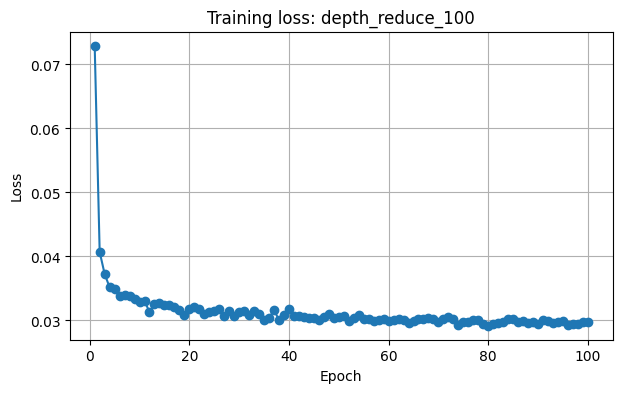

In [18]:
def plot_log(exp_name):
    path = trainlog_path(exp_name)
    if not path.exists():
        print("No log found:", path)
        return

    logs = load_json(path)
    epochs = [x["epoch"] for x in logs]
    losses = [x["loss"] for x in logs]

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, losses, marker="o")
    plt.title(f"Training loss: {exp_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

plot_log("depth_reduce_100")

In [19]:
def load_eval_model(exp_name, epoch):
    cfg = EXPS[exp_name]
    model = build_model_from_cfg(cfg)
    ema = EMA(model, decay=cfg["ema"]["decay"]) if cfg["ema"]["use"] else None

    path = milestone_full_path(exp_name, epoch)
    assert path.exists(), f"Missing checkpoint: {path}"

    ckpt = load_ckpt(path, model, opt=None, ema=ema, map_location=device)

    sampler_model = build_model_from_cfg(cfg)
    if ema is not None and ckpt.get("ema", None) is not None:
        ema.copy_to(sampler_model)
    else:
        sampler_model.load_state_dict(model.state_dict())

    diff = Diffusion(
        T=cfg["T"],
        beta_start=cfg["beta_start"],
        beta_end=cfg["beta_end"],
        device=device
    )

    return sampler_model, diff, cfg, ckpt

baseline_sampler, baseline_diff, baseline_cfg, baseline_ckpt = load_eval_model("baseline_100", 100)
depth_sampler, depth_diff, depth_cfg, depth_ckpt = load_eval_model("depth_reduce_100", 100)

print("Loaded baseline_100 epoch100")
print("Loaded depth_reduce_100 epoch100")

Loaded baseline_100 epoch100
Loaded depth_reduce_100 epoch100


In [20]:
train_loader_eval, _ = get_dataloaders(BASE)

results = []

for name, sampler_model, diff, cfg, ckpt_epoch in [
    ("baseline_100", baseline_sampler, baseline_diff, baseline_cfg, 100),
    ("depth_reduce_100", depth_sampler, depth_diff, depth_cfg, 100),
]:
    print(f"\nEvaluating {name} epoch {ckpt_epoch}")

    params, macs = compute_params_macs(sampler_model, cfg)

    qcfg = cfg["quick_eval"]
    fid_val = quick_fid(
        cfg, sampler_model, diff, train_loader_eval,
        n_real=qcfg["n_real"],
        n_fake=qcfg["n_fake"],
        ddim_steps=qcfg["ddim_steps"]
    )

    out_img = SAMPLE_DIR / f"{name}_final_quick_ddim{qcfg['ddim_steps']}.png"
    save_sample_grid(
        sampler_model, diff, cfg,
        out_img,
        n_samples=64,
        ddim_steps=qcfg["ddim_steps"]
    )

    results.append({
        "exp_name": name,
        "epoch": ckpt_epoch,
        "params": params,
        "macs": macs,
        "quick_fid": fid_val,
        "sample_path": str(out_img)
    })

df_results = pd.DataFrame(results)
df_results.to_csv(summary_csv_path(), index=False)
df_results


Evaluating baseline_100 epoch 100


DDIM sampling: 100%|██████████| 20/20 [00:00<00:00, 70.08it/s]



Evaluating depth_reduce_100 epoch 100


DDIM sampling: 100%|██████████| 20/20 [00:00<00:00, 80.14it/s]


,exp_name,epoch,params,macs,quick_fid,sample_path
0,baseline_100,100,28874371,5107875840,467.911530,/content/drive/MyDrive/CSE499B_Lightweight_Dif...
1,depth_reduce_100,100,20547459,5054136320,474.452789,/content/drive/MyDrive/CSE499B_Lightweight_Dif...


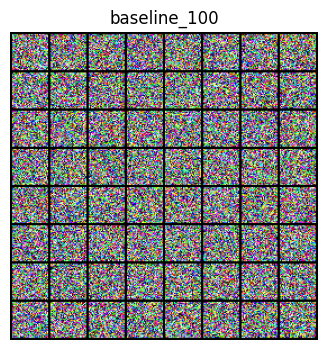

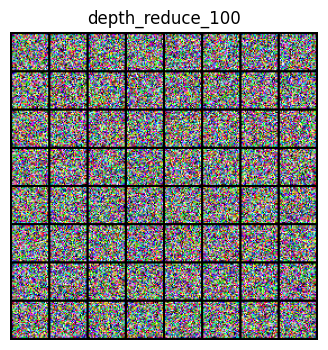

In [21]:
for name in ["baseline_100", "depth_reduce_100"]:
    candidates = sorted(SAMPLE_DIR.glob(f"{name}_*final_quick*.png"))
    if len(candidates) == 0:
        print("No final sample found for", name)
        continue

    p = candidates[-1]
    plt.figure(figsize=(4, 4))
    plt.imshow(Image.open(p))
    plt.axis("off")
    plt.title(name)
    plt.show()

In [22]:
depth75_exists = milestone_full_path("depth_reduce_100", 75).exists()
depth100_exists = milestone_full_path("depth_reduce_100", 100).exists()

if depth75_exists and depth100_exists:
    depth75_sampler, depth75_diff, depth75_cfg, _ = load_eval_model("depth_reduce_100", 75)
    depth100_sampler, depth100_diff, depth100_cfg, _ = load_eval_model("depth_reduce_100", 100)

    compare_rows = []
    for ep, sampler_model, diff, cfg in [
        (75, depth75_sampler, depth75_diff, depth75_cfg),
        (100, depth100_sampler, depth100_diff, depth100_cfg),
    ]:
        fid_val = quick_fid(
            cfg, sampler_model, diff, train_loader_eval,
            n_real=cfg["quick_eval"]["n_real"],
            n_fake=cfg["quick_eval"]["n_fake"],
            ddim_steps=cfg["quick_eval"]["ddim_steps"]
        )
        compare_rows.append({
            "exp_name": "depth_reduce_100",
            "epoch": ep,
            "quick_fid": fid_val
        })

    pd.DataFrame(compare_rows)
else:
    print("Depth-reduced epoch 75 or 100 checkpoint not found yet.")

DDIM sampling: 100%|██████████| 20/20 [00:00<00:00, 92.47it/s]


In [23]:
print_ckpt_sizes()

baseline_100_epoch100.pt                  0.43 GB
baseline_100_epoch30.pt                   0.43 GB
baseline_100_epoch50.pt                   0.43 GB
baseline_100_epoch75.pt                   0.43 GB
depth_reduce_100_best_full.pt             0.31 GB
depth_reduce_100_ema_epoch100.pt          0.08 GB
depth_reduce_100_ema_epoch75.pt           0.08 GB
depth_reduce_100_epoch100.pt              0.31 GB
depth_reduce_100_epoch30.pt               0.31 GB
depth_reduce_100_epoch50.pt               0.31 GB
depth_reduce_100_epoch75.pt               0.31 GB
depth_reduce_100_latest_full.pt           0.31 GB

Total checkpoint size: 3.72 GB


During this week, the primary objective was to continue the second-phase experimental study in a more controlled and storage-efficient manner by resuming the diffusion training workflow from previously saved milestone checkpoints instead of repeating the earlier inefficient full-checkpoint strategy. In the previous week, a major practical limitation was encountered because checkpoints had been saved after every epoch, which caused Google Drive storage to fill rapidly due to each checkpoint occupying several hundred megabytes. To address this issue, the workflow for this week was redesigned so that only important milestone checkpoints were preserved. Specifically, for the baseline model, only the 30, 50, 75, and 100 epoch checkpoints were retained, while for the depth-reduced model, the 30 and 50 epoch checkpoints were kept as continuation points. This cleanup step was necessary to free sufficient storage space and establish a more sustainable training pipeline for the remaining experiments.

After reorganizing the storage strategy, the notebook itself was updated so that it could correctly resume training from the saved depth-reduced checkpoint at epoch 50 and continue training in a staged manner up to epoch 100. This updated workflow was intentionally designed to avoid unnecessary saving overhead and to support stable execution on Google Colab Pro using an A100 GPU. Rather than saving a full checkpoint after every epoch, the new implementation saved an overwriteable latest checkpoint periodically, a best checkpoint when improvement was observed, and milestone checkpoints only at important epochs such as 75 and 100. This adjustment significantly reduced storage pressure while still preserving enough information for recovery, reproducibility, and later evaluation. During implementation, an architecture mismatch problem was discovered between the old saved checkpoints and the revised notebook model definition. This issue was resolved by restoring the original U-Net structure used in the earlier training so that the saved weights from the previous week could be loaded correctly. An additional missing timestep embedding function was also added to ensure smooth continuation of the training process.

With these corrections in place, the depth-reduced model was successfully resumed from epoch 50 and trained continuously up to epoch 100. A milestone checkpoint was saved during training at epoch 75, and the final checkpoint was saved at epoch 100. This staged continuation was important both practically and experimentally. From a practical standpoint, it reduced the risk of losing progress due to session interruptions, and from an experimental standpoint, it allowed the model’s behavior to be analyzed at meaningful milestones rather than only at the end of training. In parallel, the already completed baseline model trained to 100 epochs was used as the main reference model for final comparison. Because the current focus was on completing and validating the depth-reduced architecture against the baseline, the experiments this week emphasized depth-reduced continuation and final evaluation rather than launching additional new model variants.

At the end of training, both the baseline model at epoch 100 and the depth-reduced model at epoch 100 were evaluated using the updated quick evaluation pipeline. This evaluation setup was intentionally lightweight so that it could be executed efficiently within the available compute and storage constraints. The quick evaluation relied on DDIM sampling with a reduced number of sampling steps and a relatively small number of generated and real samples, which means that the resulting FID values are useful mainly for comparative trend analysis rather than as final publication-grade measurements. Under this setting, the baseline model achieved a quick FID of 467.91, while the depth-reduced model achieved a quick FID of 474.45. Although the depth-reduced model produced a slightly higher FID value, the difference between the two models remained relatively small in the context of such a lightweight evaluation protocol. This suggests that the depth-reduced model preserved broadly comparable generative behavior despite being computationally more compact in terms of model size.

A particularly important outcome of this week’s work is the parameter-efficiency comparison between the two architectures. The baseline model contained 28,874,371 parameters, whereas the depth-reduced model contained 20,547,459 parameters. This corresponds to a reduction of approximately 8.33 million parameters, or about 28.8% fewer parameters than the baseline. At the same time, the multiply-accumulate operation counts remained close, with the baseline requiring 5,107,875,840 MACs and the depth-reduced model requiring 5,054,136,320 MACs. These results indicate that the depth-reduced architecture achieved a substantial reduction in model size while maintaining a level of generative quality that remained close to the baseline under the quick evaluation setting. Therefore, the main experimental conclusion from this week is that reducing the network depth did not cause catastrophic performance degradation, and the efficiency–quality trade-off remains favorable for the depth-reduced design.

Overall, this week’s work made meaningful progress both technically and experimentally. On the technical side, the training and evaluation pipeline was improved to become more storage-aware, checkpoint-efficient, and resume-friendly, which is essential for running longer diffusion experiments under cloud notebook constraints. On the experimental side, the depth-reduced model was successfully extended from its previous 50-epoch state to a complete 100-epoch result, allowing a fairer end-point comparison with the baseline 100-epoch model. The quick evaluation results support the argument that the depth-reduced architecture remains a competitive lightweight alternative to the baseline while using substantially fewer parameters. The main limitation is that the current FID results were obtained under a reduced evaluation protocol and should therefore be treated as provisional indicators rather than final benchmark scores. The next logical step will be to perform a stronger GPU-based evaluation using a larger number of real and generated samples and a larger DDIM step count, such as 50 steps, so that the final thesis conclusions can be supported by more reliable quantitative evidence. Nevertheless, the present week successfully completed the remaining long-training continuation, established an efficient checkpointing strategy, and generated the first full 100-epoch comparison between the baseline and depth-reduced models under the revised experimental framework.

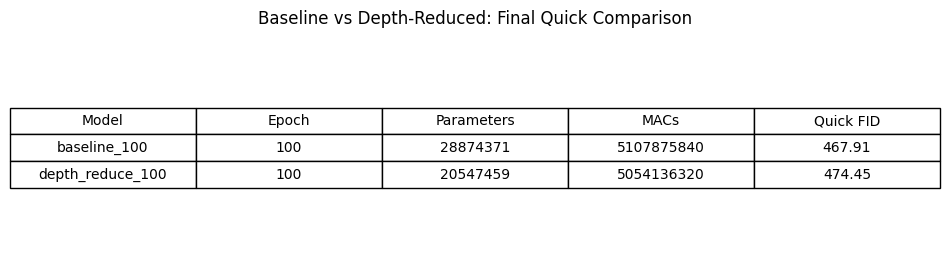

In [28]:
import matplotlib.pyplot as plt

df = pd.read_csv(summary_csv_path())
show_df = df[["exp_name", "epoch", "params", "macs", "quick_fid"]].copy()
show_df.columns = ["Model", "Epoch", "Parameters", "MACs", "Quick FID"]
show_df["Quick FID"] = show_df["Quick FID"].round(2)

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis("off")

table = ax.table(
    cellText=show_df.values,
    colLabels=show_df.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)

plt.title("Baseline vs Depth-Reduced: Final Quick Comparison", pad=20)
plt.show()